# 4 · What did the models learn?

We now inspect the selected fixed-window MLP and one-head causal-attention models using their **actual saved parameters and activations**.

```text
fair held-out metrics → embedding motion on one shared 2-D basis
→ cosine neighbours → same lookup / different contextual row
→ descriptive attention map → controlled token interventions
```

Individual learned coordinates are not labelled “water,” “finance,” or “person.” The named axes in the Part II lecture are hand-chosen teaching aids, not properties to assume of trained embeddings.


In [1]:
from pathlib import Path
import json, math, os, sys, time

HERE = Path.cwd()
if not (HERE / "wordlm.py").exists():
    matches = list(Path.cwd().rglob("word-level-next-token/wordlm.py"))
    if not matches:
        raise FileNotFoundError("Run this notebook from its word-level-next-token directory.")
    HERE = matches[0].parent
sys.path.insert(0, str(HERE))

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from wordlm import *

SEED = 11
seed_everything(SEED)
DEVICE = resolve_device(os.getenv("WORDLM_DEVICE", "auto"))
plt.style.use("seaborn-v0_8-whitegrid")
print(f"torch={torch.__version__}  device={DEVICE}")


torch=2.14.0  device=mps


In [2]:
ARTIFACTS = HERE / "artifacts"
benchmark = read_json(ARTIFACTS / "benchmark.json")
vocab_data = read_json(ARTIFACTS / "vocab.json")
itos = vocab_data["itos"]
vocab = Vocabulary(itos, {token:i for i,token in enumerate(itos)}, vocab_data["counts"],
                   vocab_data["max_vocab"], vocab_data["min_freq"])
print("source revision:", benchmark["source"]["dataset_revision"])
print("profile:", benchmark["protocol"]["profile"], "seeds:", benchmark["protocol"]["seeds"])
print("comparison protocol:", {k:v for k,v in benchmark["protocol"].items() if k.startswith("same_")})


source revision: f54c09fd23315a6f9c86f9dc80f725de7d8f9c64
profile: dgx seeds: [11, 29, 47]
comparison protocol: {'same_context_length': 64, 'same_documents_tokenizer_vocabulary_targets': True, 'same_embedding_width': True, 'same_hidden_width': True, 'same_steps_batch_size_and_seeds': True}


## 1. Did attention improve the natural-corpus benchmark?

Both models use the same documents, normalization, train-only vocabulary, **64-word context**, target windows, seed set, batch size, maximum supervised-token budget, and token-weighted loss. Both predict one target per window, avoiding a hidden all-positions versus one-position accounting advantage. Within the shared 6,000-step ceiling, each run restores its lowest-validation-loss checkpoint before the test is evaluated; the chosen step is reported rather than hidden.


In [3]:
print(f"{'model':>10} {'params':>11} {'max tokens':>11} {'selected steps':>17} {'test CE mean±sd':>20} {'test PPL mean±sd':>20} {'runtime mean':>14}")
for kind in ["mlp", "attention"]:
    runs = benchmark["runs"][kind]
    agg = benchmark["aggregate"][kind]
    selected_steps = ",".join(str(r["selected_step"]) for r in runs)
    print(f"{kind:>10} {runs[0]['parameter_count']:11,d} {runs[0]['tokens_seen']:11,d} {selected_steps:>17s} "
          f"{agg['test_loss']['mean']:8.4f}±{agg['test_loss']['sample_std']:.4f} "
          f"{agg['test_perplexity']['mean']:8.2f}±{agg['test_perplexity']['sample_std']:.2f} "
          f"{agg['runtime_seconds']['mean']:12.1f}s")
print("\nmeasured conclusion:", benchmark["comparison"])


     model      params  max tokens    selected steps      test CE mean±sd     test PPL mean±sd   runtime mean
       mlp   2,332,832   3,072,000    2250,2250,2250   3.9399±0.0086    51.41±0.44         67.8s
 attention   1,321,120   3,072,000    6000,5250,4500   3.4441±0.0097    31.31±0.30         71.5s

measured conclusion: {'attention_minus_mlp_test_loss': -0.4958402656538552, 'claim_scope': 'bounded TinyStories subset and the documented training budget only', 'relative_perplexity_change': -0.39093694867207696, 'winner': 'attention'}


Interpret the sign of `attention_minus_mlp_test_loss` directly: negative favours attention. The claim is limited to this bounded subset and budget. Multiple seeds expose optimization variation; they do not turn one classroom experiment into a universal architecture result.

## 2. Load safe, compact NumPy checkpoints

These `.npz` files contain arrays and JSON only; `allow_pickle=False` is enforced. We inspect seed 11 and keep the three-seed metric table above as the quality result.


In [4]:
mlp_cfg = benchmark["configs"]["mlp"]
attn_cfg = benchmark["configs"]["attention"]
mlp = FixedWindowMLP(len(itos), mlp_cfg["context_len"], mlp_cfg["d_embed"], mlp_cfg["hidden"], vocab.pad_id)
attention = CausalAttentionLM(len(itos), attn_cfg["context_len"], attn_cfg["d_embed"],
                             attn_cfg["d_embed"], attn_cfg["d_embed"], attn_cfg["hidden"], vocab.pad_id)
mlp_meta, mlp_trace = load_model_npz(ARTIFACTS / "mlp_seed11.npz", mlp)
attn_meta, attn_trace = load_model_npz(ARTIFACTS / "attention_seed11.npz", attention)
mlp.eval(); attention.eval()
print("MLP checkpoints:", list(mlp_trace), "attention checkpoints:", list(attn_trace))


MLP checkpoints: ['step_0', 'selected_step_2250'] attention checkpoints: ['step_0', 'step_3000', 'selected_step_6000']


## 3. Embedding movement on one shared basis

Fitting a separate PCA panel at each checkpoint can make a stationary point appear to rotate or reflect. We fit **one** global two-dimensional basis to all lexical embeddings from both models and all checkpoints, then reuse it everywhere.


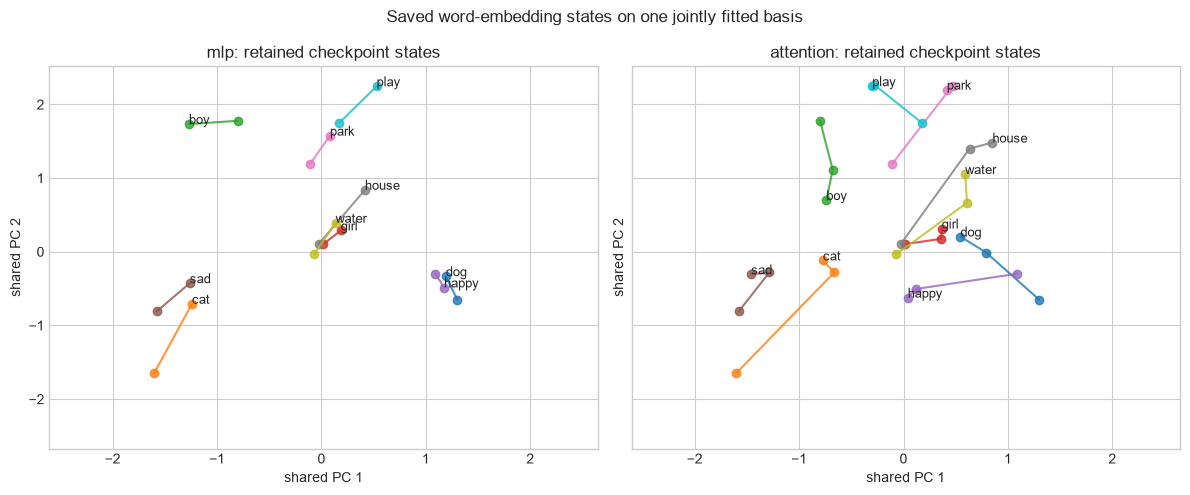

In [5]:
selected_words = [word for word in ["dog","cat","boy","girl","happy","sad","park","house","water","play"] if word in vocab.stoi]
all_traces = list(mlp_trace.values()) + list(attn_trace.values())
mean, basis = fit_common_pca([array[4:] for array in all_traces])
projected = {
    "mlp": {name: project_with_basis(array, mean, basis) for name,array in mlp_trace.items()},
    "attention": {name: project_with_basis(array, mean, basis) for name,array in attn_trace.items()},
}
coords = np.concatenate([p for model_trace in projected.values() for p in model_trace.values()])
lexical = coords[4:]
xlim = np.percentile(lexical[:,0], [1,99]); ylim = np.percentile(lexical[:,1], [1,99])

fig, panels = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, kind, trace in zip(panels, ["mlp","attention"], [mlp_trace, attn_trace]):
    names = list(trace)
    for word in selected_words:
        idx = vocab.stoi[word]
        path = np.array([projected[kind][name][idx] for name in names])
        ax.plot(path[:,0], path[:,1], "o-", alpha=.8)
        ax.text(path[-1,0], path[-1,1], word, fontsize=9)
        ax.set(title=f"{kind}: retained checkpoint states", xlabel="shared PC 1", ylabel="shared PC 2",
           xlim=xlim, ylim=ylim)
fig.suptitle("Saved word-embedding states on one jointly fitted basis")
fig.tight_layout(); plt.show()


The arrows are descriptive movement in a shared projection. They do not prove what any individual dimension “means,” and the two-dimensional view discards most of the learned space.

## 4. Cosine neighbours and similarities


In [6]:
for kind, trace in [("mlp", mlp_trace), ("attention", attn_trace)]:
    final_name = list(trace)[-1]
    embedding = trace[final_name]
    print(f"\n{kind.upper()} final embedding neighbours")
    for word in [w for w in ["dog","happy","park","water"] if w in vocab.stoi]:
        print(f"{word:>7s}:", cosine_neighbors(embedding, vocab, word, top_k=6))



MLP final embedding neighbours
    dog: [('blackboard', 0.4288909871343894), ('raising', 0.42499166999305404), ('clown', 0.4024421810138985), ('carry', 0.3869310122609408), ('sharkey', 0.38164856082957355), ('crayon', 0.3806424024947795)]
  happy: [('sport', 0.4331433435922624), ('picking', 0.3863059992301754), ('get', 0.37572263222089314), ('exhausted', 0.37413326867714514), ('pit', 0.3703120812495631), ('sally', 0.3674784878306193)]
   park: [('picks', 0.455092030338458), ('james', 0.4200555262709615), ('dream', 0.41011659034796466), ('borrowed', 0.40910655272729185), ('eat', 0.3934765942476569), ('ache', 0.3872221724237042)]
  water: [('over', 0.5010160246202907), ('mask', 0.4758670597632587), ('loop', 0.449909598493456), ('follows', 0.4219477344183188), ('listening', 0.39579735762505247), ('visiting', 0.3838441624927729)]

ATTENTION final embedding neighbours
    dog: [('amy', 0.4550882157595434), ('blackboard', 0.45415043593600457), ('clown', 0.42865725427385726), ('cat', 0.40435

  happy: [('sport', 0.4942735791034914), ('ellie', 0.43001242740551654), ('special', 0.413900006824243), ('exhausted', 0.39579993509900335), ('tiny', 0.38049605699714023), ('receive', 0.36744251993473814)]
   park: [('tricks', 0.4598901762759206), ('ache', 0.42925085410670966), ('writes', 0.4205980852861891), ('officer', 0.41977967837485), ('lake', 0.4011580941580433), ('twig', 0.37922215071944054)]
  water: [('mask', 0.5584840634540089), ('loop', 0.42609889866584405), ('listening', 0.4156960620471104), ('gardens', 0.4126919228066015), ('zipper', 0.39918061374781083), ('texture', 0.3922245176411231)]


Neighbours summarize similarity under the learned lookup geometry. They are corpus- and seed-dependent descriptions, not dictionary definitions.

## 5. Same word lookup, different contextual representations

A lookup row is static. In the attention model, the contextual row also depends on the other words and positions in that occurrence.


In [7]:
def context_tensor(text):
    ids = [vocab.bos_id] + vocab.encode_tokens(tokenize(text), boundaries=False)
    ids = ids[-attn_cfg["context_len"]:]
    ids = [vocab.pad_id] * (attn_cfg["context_len"] - len(ids)) + ids
    return torch.tensor([ids], dtype=torch.long)

sentences = ["the children like to play", "the dog and the cat play"]
contexts = [context_tensor(text) for text in sentences]
assert all(vocab.itos[int(ctx[0,-1])] == "play" for ctx in contexts)
lookup_a = attention.token_embedding(contexts[0])[0,-1]
lookup_b = attention.token_embedding(contexts[1])[0,-1]
with torch.no_grad():
    contextual = [attention.forward_details(ctx)["contextual"][0,-1] for ctx in contexts]
print("lookup rows identical:", torch.equal(lookup_a, lookup_b))
print("lookup cosine:", float(F.cosine_similarity(lookup_a[None], lookup_b[None])))
print("contextual cosine:", float(F.cosine_similarity(contextual[0][None], contextual[1][None])))
print("contextual L2 distance:", float(torch.linalg.vector_norm(contextual[0]-contextual[1])))


lookup rows identical: True
lookup cosine: 0.9999998807907104
contextual cosine: 0.8527709245681763
contextual L2 distance: 6.008221626281738


/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_16093/3584222066.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("lookup cosine:", float(F.cosine_similarity(lookup_a[None], lookup_b[None])))


The same word has one shared lookup row, but its occurrence-specific representation changes after attention and the residual update. That is the central representational difference from the baseline's static lookup table.

## 6. An attention heatmap is descriptive


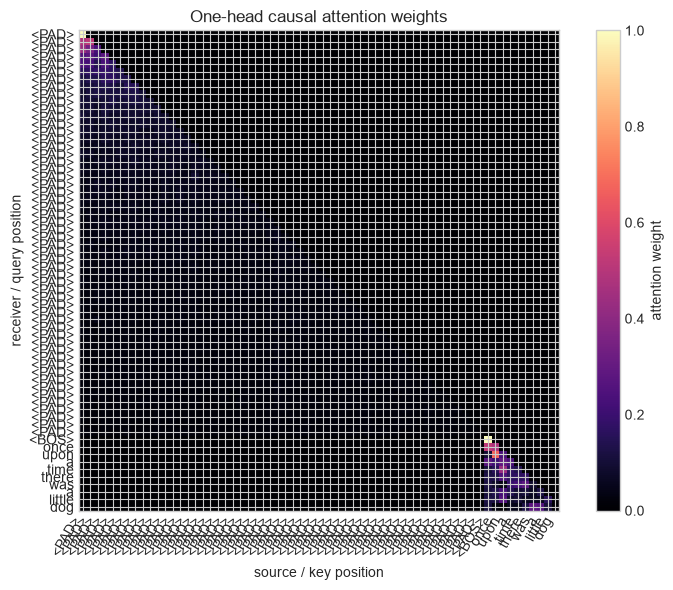

In [8]:
probe_text = "once upon a time there was a little dog"
probe = context_tensor(probe_text)
labels = vocab.decode_ids(probe[0], skip_special=False)
with torch.no_grad():
    details = attention.forward_details(probe)
A = details["weights"][0].numpy()
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(A, cmap="magma", vmin=0, vmax=A.max())
ax.set(xticks=range(len(labels)), yticks=range(len(labels)), xticklabels=labels, yticklabels=labels,
       xlabel="source / key position", ylabel="receiver / query position", title="One-head causal attention weights")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
fig.colorbar(image, ax=ax, label="attention weight"); fig.tight_layout(); plt.show()


A bright cell says that this head assigned a large mixing weight on this forward pass. It does **not** by itself establish that the source token caused the prediction, that it is an explanation a human would endorse, or that another head/block agrees—there are no other heads or blocks here.

## 7. Controlled token interventions

We now change exactly one earlier token to `<UNK>` and recompute the whole model. This is causal evidence about this intervention on this trained model, though still not a general linguistic explanation.


In [9]:
final_weights = details["weights"][0,-1].clone()
eligible = [i for i,tok in enumerate(labels[:-1]) if tok not in (PAD, BOS)]
high = max(eligible, key=lambda i: float(final_weights[i]))
low = min(eligible, key=lambda i: float(final_weights[i]))

def intervene(model, position):
    changed = probe.clone()
    changed[0, position] = vocab.unk_id
    with torch.no_grad():
        return model(probe)[0], model(changed)[0]

with torch.no_grad():
    base_distribution = F.softmax(attention(probe)[0], dim=-1)
    target_id = int(base_distribution.argmax())
print("unmodified top prediction:", vocab.itos[target_id], float(base_distribution[target_id]))
for label, position in [("high-attention", high), ("low-attention", low)]:
    before, after = intervene(attention, position)
    p, q = F.softmax(before, -1), F.softmax(after, -1)
    kl = float((p * (p.clamp_min(1e-12).log() - q.clamp_min(1e-12).log())).sum())
    print(f"\n{label} source: position={position}, token={labels[position]!r}, weight={float(final_weights[position]):.3f}, KL={kl:.5f}")
    print(top_probability_changes(before, after, vocab, top_k=5))


unmodified top prediction: named 0.7955166697502136

high-attention source: position=60, token='was', weight=0.282, KL=0.25429
[{'token': 'named', 'before': 0.7955166697502136, 'after': 0.6062367558479309, 'delta': -0.18927991390228271}, {'token': '.', 'before': 0.05514321103692055, 'after': 0.14808408915996552, 'delta': 0.09294088184833527}, {'token': 'who', 'before': 0.07126147300004959, 'after': 0.01596684940159321, 'delta': -0.05529462546110153}, {'token': 'came', 'before': 0.0009132049162872136, 'after': 0.04255768284201622, 'delta': 0.04164447635412216}, {'token': 'and', 'before': 0.0172231737524271, 'after': 0.04486595094203949, 'delta': 0.02764277718961239}]

low-attention source: position=56, token='upon', weight=0.000, KL=0.00121
[{'token': '.', 'before': 0.05514321103692055, 'after': 0.0624932162463665, 'delta': 0.007350005209445953}, {'token': 'who', 'before': 0.07126147300004959, 'after': 0.06431179493665695, 'delta': -0.006949678063392639}, {'token': 'named', 'before': 0.

Compare the heatmap with the intervention: a larger attention weight need not imply a proportionally larger prediction change because values, output projection, residual addition, and the nonlinear vocabulary MLP all intervene. The ablation is more causally informative than the heatmap, but it is still a particular replacement (`<UNK>`) in one context.

**Bottom line.** The held-out metric establishes which architecture performed better here; embedding and attention plots describe mechanisms and geometry; controlled interventions test specific causal sensitivities. None justifies naming individual trained coordinates or treating attention weights alone as explanations.
